**건강검진 데이터 시각화하기**
---
> **목차(Context)**

* 데이터 살펴보기
* EDA

In [ ]:
### 개발환경 세팅하기

# ▶ 한글 폰트 다운로드
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 45 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (28.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121918 files and direc

In [ ]:
# ▶ 한글 폰트 설정하기
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

# ▶ Warnings 제거
import warnings
warnings.filterwarnings('ignore')

# ▶ Google drive mount or 폴더 클릭 후 구글드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **데이터 준비하기**
---

> **데이터 준비하기**

- 데이터 출처 : [공공데이터 포털](https://www.data.go.kr/data/15007122/fileData.do#/layer_data_infomation) `국민건강보험공단_건강검진정보`

    - 본 미션에서는 2022년 버전을 사용합니다. '국민건강보험공단_건강검진정보_20221231.CSV' 파일을 찾아 import 해주세요.

- 데이터 명세  

| No. | 표준항목명          | 영문명            | 설명                                                                                                           | 표현형식/단위          | 예시         |
|-----|-----------------|------------------|---------------------------------------------------------------------------------------------------------------|---------------------|--------------|
| 1   | 기준년도          | HCHK_YEAR        | 해당 정보의 기준년도를 제공함                                                                                  | YYYY                | 2009         |
| 2   | 가입자일련번호       | IDV_ID           | 해당가입자에 부여한 일련번호                                                                                  | 1 ~ 1,000,000       | 1            |
| 3   | 시도코드          | SIDO             | 해당 수진자 거주지의 시도코드                                                                                  | -                   | 26           |
| 4   | 성별              | SEX              | 해당 정보 대상자의 성별을 제공함                                                                               | 성별 : 1(남자), 2(여자) | 1            |
| 5   | 연령대코드(5세단위)    | AGE_GROUP        | 기준년도에 수진자의 나이를 5세 단위로 그룹화하여 구분한 코드                                                     | 5세 단위 그룹화, 85세 이상은 85+로 그룹화 | -            |
| 6   | 신장(5cm단위)     | HEIGHT           | 검진자의 키(5CM 단위)                                                                                          | N/Cm                | 140          |
| 7   | 체중(5kg단위)     | WEIGHT           | 검진자의 몸무게(5KG 단위)                                                                                      | N/Kg                | 45           |
| 8   | 허리둘레          | WAIST            | 검진자의 허리둘레                                                                                              | N/Cm                | 82           |
| 9   | 시력(좌)          | SIGHT_LEFT       | 수검자의 좌측 눈의 시력                                                                                        | N                   | 0.5          |
| 10  | 시력(우)          | SIGHT_RIGHT      | 수검자의 우측 눈의 시력                                                                                        | N                   | 0.5          |
| 11  | 청력(좌)          | HEAR_LEFT        | 수검자의 좌측 귀의 청력                                                                                        | N                   | 1            |
| 12  | 청력(우)          | HEAR_RIGHT       | 수검자의 우측 귀의 청력                                                                                        | N                   | 1            |
| 13  | 수축기혈압         | BP_HIGH          | 검진자의 최고 혈압으로 심장이 수축해서 강한 힘으로 혈액을 동맥에 보낼 때의 혈관 내압                                   | N/mmHg              | 140          |
| 14  | 이완기혈압         | BP_LWST          | 검진자의 최저 혈압으로 심장의 완기시의 혈압                                                                      | N/mmHg              | 81           |
| 15  | 식전혈당(공복혈당)    | BLDS             | 검진자 식사 전 혈당(혈액 100ml당 함유 되어 있는 포도당의 농도) 수치                                               | N/mg/dL             | 94           |
| 16  | 총콜레스테롤        | TOT_CHOLE        | 혈청 중의 에스텔형, 비에스테형(유리)콜레스테롤의 합                                                               | N/mg/dL             | 164          |
| 17  | 트리글리세라이드    | TRIGLYCERIDE     | 단순지질 혹은 중성지질을 뜻함                                                                                    | N/mg/dL             | 94           |
| 18  | HDL콜레스테롤      | HDL_CHOLE        | HDL(고밀도 리포단백질)에 포함되는 콜레스테롤                                                                      | N/mg/dL             | 45           |
| 19  | LDL콜레스테롤      | LDL_CHOLE        | LDL(저밀도 리포단백질)에 함유된 콜레스테롤                                                                        | N/mg/dL             | 150, 130     |
| 20  | 혈색소            | HMG              | 혈액이나 혈구 속에 존재하는 색소단백으로 글로빈(globin)과 엠(heme)으로 구성되며 혈중의 산소운반체로서의 역할 수행       | N/g/dL              | 15.3984375   |
| 21  | 요단백            | OLIG_PROTE_CD    | 소변에 단백질이 섞여 나오는 것                                                                                  | N                   | 1            |
| 22  | 혈청크레아티닌       | CREATININE       | 크레아틴의 탈수물로 내인성 단백대사의 종말산물로서 신장에서 배설되고 그 증감은 음식물에 관계없이 근육의 발육과 운동에 관계함 | N/mg/dL             | 0.8          |
| 23  | 혈청지오티(AST)    | AST              | 간 기능을 나타내는 혈액검사상의 수치, 간세포 이외에 심장, 신장, 뇌, 근육 등에도 존재하는 효소로 이러한 세포들이 손상을 받는 경우 농도가 증가함 | N/IU/L              | 12           |
| 24  | 혈청지피티(ALT)    | ALT              | 간 기능을 나타내는 혈액검사상의 수치, ALT는 주로 간세포 안에 존재하는 효소로, 간세포가 손상을 받는 경우 농도가 증가함        | N/U/L               | 15           |
| 25  | 감마지티피         | GAMMA_GTP        | 간 기능을 나타내는 혈액검사상의 수치, 간 내의 쓸개관(담관)에 존재하는 효소로 글루타민산을 외부에 펩티드나 아미노산 등으로 옮기는 작용을 함 | N/U/L               | 119, 114     |
| 26  | 흡연상태           | SMK_STAT_TYPE_CD | 해당 수검자의 흡연 상태 여부                                                                                    | N                   | 1            |
| 27  | 음주여부           | DRK_YN           | 해당 수검자의 음주 상태 여부                                                                                    | N/Y                 | 1            |
| 28  | 구강검진수검여부     | HCHK_OE_INSPEC_YN | 해당 검진자가 구강검진을 선택하여 검진하였는지 여부에 대한 항목                                                   | N/Y                 | 1            |
| 29  | 치아우식증유무       | CRS_YN           | 해당 수검자의 치아우식증 유무                                                                                   | N                   | 1            |
| 30  | 치석              | TTR_YN           | 해당 수검자의 치석 여부                                                                                         | N/Y                 | 1            |

     


In [169]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [170]:
# Pandas 보기 옵션
pd.set_option('display.max_columns',100)

### 문제1. 데이터 불러오기
: 제공된 `./국민건강보험공단_건강검진정보_20221231.CSV` 파일을 불러오세요. 한글 폰트가 깨질 경우, 인코딩을 확인해보세요.

In [171]:
df = pd.read_csv("../data/health5.csv", encoding="cp949")


## **EDA : Data 살펴보기**  
---

* 수집된 데이터의 기본 정보들을 확인  

  (1) Data shape(형태) 확인

  (2) Data type 확인

  (3) Null값 확인 (※ 빈 값의 Data)

  (4) Outlier 확인 (※ 정상적인 범주를 벗어난 Data)  

### 전체적인 데이터 살펴보기

#### 문제2. 데이터의 형태를 확인해보세요.
- 몇 개의 데이터가 존재하나요?
- 몇 개의 특성이 존재하나요?

In [172]:
df.shape

(1000000, 30)

#### 문제3. 데이터의 타입을 확인해보세요.
- 어떤 특성들이 데이터에 포함되어 있나요?
- 각 특성의 값은 어떤 데이터 타입으로 구성되어 있나요?

In [173]:
df.dtypes


기준년도             int64
가입자일련번호          int64
시도코드             int64
성별               int64
연령대코드(5세단위)      int64
신장(5cm단위)        int64
체중(5kg단위)        int64
허리둘레           float64
시력(좌)          float64
시력(우)          float64
청력(좌)          float64
청력(우)          float64
수축기혈압          float64
이완기혈압          float64
식전혈당(공복혈당)     float64
총콜레스테롤         float64
트리글리세라이드       float64
HDL콜레스테롤       float64
LDL콜레스테롤       float64
혈색소            float64
요단백            float64
혈청크레아티닌        float64
혈청지오티(AST)     float64
혈청지피티(ALT)     float64
감마지티피          float64
흡연상태           float64
음주여부           float64
구강검진수검여부         int64
치아우식증유무        float64
치석             float64
dtype: object

In [174]:
df.head(30)

,기준년도,가입자일련번호,시도코드,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
0,2022,702763,41,2,14,160,75,89.0,1.0,1.0,1.0,1.0,127.0,73.0,84.0,NaN,NaN,NaN,NaN,14.8,1.0,0.8,25.0,20.0,15.0,1.0,0.0,0,NaN,NaN
1,2022,765435,41,2,9,150,45,68.0,1.0,1.0,1.0,1.0,127.0,75.0,85.0,NaN,NaN,NaN,NaN,13.1,1.0,0.8,19.0,10.0,7.0,1.0,1.0,0,NaN,NaN
2,2022,343621,41,2,13,150,60,78.8,1.0,1.0,1.0,1.0,135.0,81.0,105.0,NaN,NaN,NaN,NaN,13.0,1.0,0.8,17.0,15.0,15.0,1.0,1.0,0,NaN,NaN
3,2022,3393534,41,2,6,160,50,69.0,1.0,1.0,1.0,1.0,109.0,70.0,81.0,NaN,NaN,NaN,NaN,13.4,1.0,0.8,25.0,16.0,13.0,1.0,1.0,0,NaN,NaN
4,2022,1716951,41,2,7,160,55,75.0,1.0,1.0,1.0,1.0,110.0,67.0,79.0,NaN,NaN,NaN,NaN,14.7,1.0,0.8,22.0,22.0,15.0,1.0,1.0,0,NaN,NaN
5,2022,4207013,41,1,7,170,85,93.5,1.0,1.0,1.0,1.0,136.0,89.0,92.0,NaN,NaN,NaN,NaN,15.8,1.0,0.8,19.0,31.0,29.0,1.0,1.0,0,NaN,NaN
6,2022,1773908,41,2,5,160,40,57.0,1.0,1.0,1.0,1.0,100.0,60.0,85.0,NaN,NaN,NaN,NaN,11.9,1.0,0.8,23.0,10.0,10.0,1.0,1.0,0,NaN,NaN
7,2022,4265572,41,1,7,180,65,74.8,1.0,1.0,1.0,1.0,110.0,80.0,94.0,NaN,NaN,NaN,NaN,16.5,1.0,0.8,13.0,10.0,19.0,1.0,1.0,0,NaN,NaN
8,2022,2303478,41,2,6,155,50,66.0,1.0,1.0,1.0,1.0,102.0,70.0,108.0,NaN,NaN,NaN,NaN,13.1,1.0,0.8,9.0,7.0,20.0,1.0,1.0,0,NaN,NaN
9,2022,4099406,41,2,6,165,55,68.0,1.0,1.0,1.0,1.0,120.0,80.0,85.0,NaN,NaN,NaN,NaN,15.4,1.0,0.8,32.0,33.0,20.0,1.0,1.0,0,NaN,NaN


#### 문제4 : 결측치 확인하기
- 각 특성 별로 결측치 개수와 비율을 확인해보세요.
- 결측치의 양상이 특성마다 차이가 난다면, 왜 그런 차이가 발생했을까요?

In [175]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 30 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   기준년도         1000000 non-null  int64  
 1   가입자일련번호      1000000 non-null  int64  
 2   시도코드         1000000 non-null  int64  
 3   성별           1000000 non-null  int64  
 4   연령대코드(5세단위)  1000000 non-null  int64  
 5   신장(5cm단위)    1000000 non-null  int64  
 6   체중(5kg단위)    1000000 non-null  int64  
 7   허리둘레         999608 non-null   float64
 8   시력(좌)        999814 non-null   float64
 9   시력(우)        999815 non-null   float64
 10  청력(좌)        999885 non-null   float64
 11  청력(우)        999884 non-null   float64
 12  수축기혈압        994444 non-null   float64
 13  이완기혈압        994444 non-null   float64
 14  식전혈당(공복혈당)   994389 non-null   float64
 15  총콜레스테롤       345618 non-null   float64
 16  트리글리세라이드     345614 non-null   float64
 17  HDL콜레스테롤     345614 non-null   float64
 18  LDL

#### 문제5 : 결측치 시각화하기
- 데이터프레임에서 결측치가 존재하는 부분을 시각화해보세요.

<Axes: >

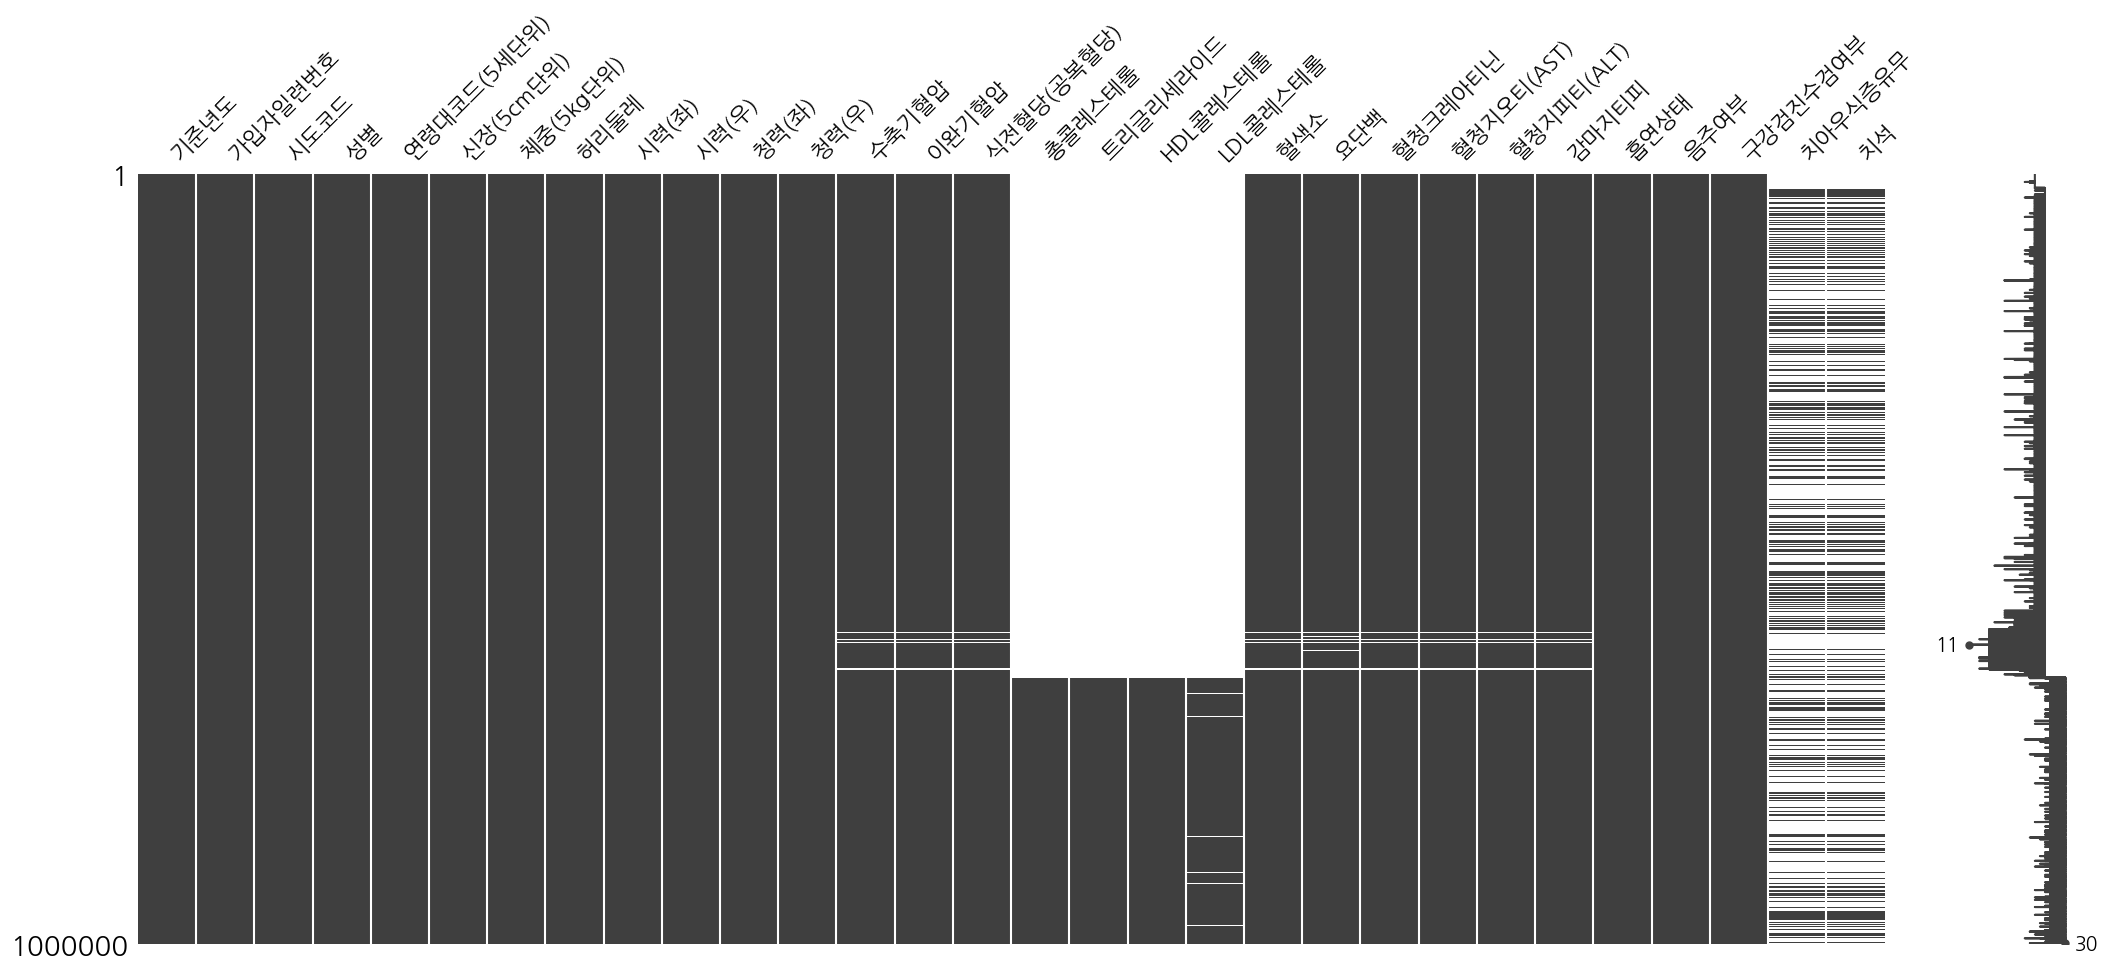

In [160]:
!pip install missingno
import missingno as msno
import koreanize_matplotlib
df = pd.read_csv('../data/health5.csv',encoding='euc-kr')
msno.matrix(df)

In [176]:
mean7=round(df['허리둘레'].mean(),1)
df['허리둘레']=df['허리둘레'].fillna(mean7)
mean8=round(df['시력(좌)'].mean(),1)
df['시력(좌)']=df['시력(좌)'].fillna(mean8)
mean9=round(df['시력(우)'].mean(),1)
df['시력(우)']=df['시력(우)'].fillna(mean9)
mean10=round(df['청력(좌)'].mean(),1)
df['청력(좌)']=df['청력(좌)'].fillna(mean10)
mean11=round(df['청력(우)'].mean(),1)
df['청력(우)']=df['청력(우)'].fillna(mean11)
mean12=round(df['수축기혈압'].mean(),1)
df['수축기혈압']=df['수축기혈압'].fillna(mean12)
mean13=round(df['이완기혈압'].mean(),1)
df['이완기혈압']=df['이완기혈압'].fillna(mean13)
mean14=round(df['식전혈당(공복혈당)'].mean(),1)
df['식전혈당(공복혈당)']=df['식전혈당(공복혈당)'].fillna(mean14)
df = df.fillna({
    "총콜레스테롤": round(df["총콜레스테롤"].mean(),1),
    "트리글리세라이드": round(df["트리글리세라이드"].mean(),1),
    "HDL콜레스테롤": round(df["HDL콜레스테롤"].mean(),1),
    "LDL콜레스테롤": round(df["LDL콜레스테롤"].mean(),1),
    "혈색소": round(df["혈색소"].mean(),1),
    "요단백": round(df["요단백"].mean(),0),
    "혈청크레아티닌": round(df["혈청크레아티닌"].mean(),1),
    "혈청지오티(AST)": round(df["혈청지오티(AST)"].mean(),1),
    "혈청지피티(ALT)": round(df["혈청지피티(ALT)"].mean(),1),
    "감마지티피": round(df["감마지티피"].mean(),1),
    "흡연상태": df["흡연상태"].mode(),
    "음주여부": df["음주여부"].mode(),
    "치아우식증유무": df["치아우식증유무"].mode(),
    "치석": df["치석"].mode()
})
df= df.dropna()

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 344268 entries, 0 to 999998
Data columns (total 30 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   기준년도         344268 non-null  int64  
 1   가입자일련번호      344268 non-null  int64  
 2   시도코드         344268 non-null  int64  
 3   성별           344268 non-null  int64  
 4   연령대코드(5세단위)  344268 non-null  int64  
 5   신장(5cm단위)    344268 non-null  int64  
 6   체중(5kg단위)    344268 non-null  int64  
 7   허리둘레         344268 non-null  float64
 8   시력(좌)        344268 non-null  float64
 9   시력(우)        344268 non-null  float64
 10  청력(좌)        344268 non-null  float64
 11  청력(우)        344268 non-null  float64
 12  수축기혈압        344268 non-null  float64
 13  이완기혈압        344268 non-null  float64
 14  식전혈당(공복혈당)   344268 non-null  float64
 15  총콜레스테롤       344268 non-null  float64
 16  트리글리세라이드     344268 non-null  float64
 17  HDL콜레스테롤     344268 non-null  float64
 18  LDL콜레스테롤     344268 non-null 

#### 문제6 : 중복값 확인하기
- 데이터에 중복값이 있는 지 확인해보세요. 만약 있다면, 제거하세요.

In [178]:
df.duplicated()
df.duplicated().sum()
df[df.duplicated(subset="가입자일련번호")]
# 없음

,기준년도,가입자일련번호,시도코드,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석


#### 문제7 : 연령대 코드 수정하기
- 현재 데이터는 연령대를 코드로 제공하고 있습니다. 연령대 코드가 의미하는 바는 다음 표와 같습니다.
- `연령대`라는 새로운 열을 만들고, 연령대 코드를 의미하는 연령대로 매핑해보세요.

In [179]:
# 연령대 코드 매핑
age_group_mapping = {
    1: "0-4", 2: "5-9", 3: "10-14", 4: "15-19", 5: "20-24",
    6: "25-29", 7: "30-34", 8: "35-39", 9: "40-44", 10: "45-49",
    11: "50-54", 12: "55-59", 13: "60-64", 14: "65-69", 15: "70-74",
    16: "75-79", 17: "80-84", 18: "85+"
}

In [180]:
# 연령대 코드를 새로운 매핑으로 업데이트 해보세요
df['연령대코드(5세단위)'] = df['연령대코드(5세단위)'].apply(lambda x : age_group_mapping[x])

In [181]:
df["연령대코드(5세단위)"].unique()
df

,기준년도,가입자일련번호,시도코드,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
0,2022,702763,41,2,65-69,160,75,89.0,1.0,1.0,1.0,1.0,127.0,73.0,84.0,198.0,131.9,56.9,115.5,14.8,1.0,0.8,25.0,20.0,15.0,1.0,0.0,0,0.0,1.0
18435,2022,443680,41,2,30-34,155,60,80.0,1.0,1.2,1.0,1.0,112.0,70.0,89.0,198.0,131.9,56.9,115.5,11.7,1.0,0.8,18.0,12.0,8.0,1.0,0.0,1,0.0,1.0
18440,2022,4889777,41,1,35-39,170,80,85.0,1.0,1.5,1.0,1.0,167.0,96.0,96.0,198.0,131.9,56.9,115.5,15.5,1.0,0.8,20.0,22.0,52.0,2.0,1.0,1,1.0,1.0
18441,2022,2907679,41,1,65-69,165,60,85.0,0.5,0.9,1.0,1.0,130.0,80.0,147.0,198.0,131.9,56.9,115.5,14.5,1.0,0.8,26.0,19.0,24.0,1.0,1.0,1,0.0,1.0
18442,2022,4631243,41,1,35-39,170,70,85.0,1.0,0.5,1.0,1.0,130.0,80.0,89.0,198.0,131.9,56.9,115.5,15.6,1.0,0.8,20.0,13.0,33.0,1.0,1.0,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999992,2022,3846447,41,1,35-39,180,85,84.9,1.0,1.0,1.0,1.0,131.0,83.0,85.0,191.0,90.0,51.0,122.0,13.0,1.0,0.8,43.0,34.0,13.0,1.0,1.0,1,0.0,1.0
999993,2022,4777440,48,2,65-69,150,70,96.4,0.9,1.2,1.0,1.0,116.0,72.0,149.0,151.0,102.0,47.0,84.0,13.8,1.0,0.8,48.0,49.0,17.0,1.0,0.0,1,0.0,0.0
999994,2022,182319,28,1,65-69,165,105,109.1,0.7,0.8,1.0,1.0,142.0,92.0,163.0,132.0,94.0,39.0,74.0,15.8,1.0,1.1,79.0,55.0,99.0,2.0,1.0,1,0.0,0.0
999995,2022,2134210,43,1,25-29,170,90,98.8,1.2,1.2,1.0,1.0,128.0,84.0,88.0,245.0,150.0,35.0,180.0,15.8,1.0,0.9,95.0,251.0,77.0,1.0,1.0,1,0.0,0.0


### 개별 데이터 살펴보기

#### 문제8 : 수치형 데이터와 범주형 데이터 구분하기
- 수치형 데이터와 범주형 데이터는 데이터를 살펴보는데 차이가 있습니다. 수치형 데이터와 범주형 데이터를 구분하세요.

In [182]:
# 범주형 데이터
df[['성별','흡연상태','음주여부','구강검진수검여부',	'치아우식증유무',	'치석']]=df[['성별','흡연상태','음주여부','구강검진수검여부',	'치아우식증유무',	'치석']].astype('str')
category_df = df.select_dtypes(exclude=['number'])
category_df

,성별,연령대코드(5세단위),흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
0,2,65-69,1.0,0.0,0,0.0,1.0
18435,2,30-34,1.0,0.0,1,0.0,1.0
18440,1,35-39,2.0,1.0,1,1.0,1.0
18441,1,65-69,1.0,1.0,1,0.0,1.0
18442,1,35-39,1.0,1.0,1,0.0,0.0
...,...,...,...,...,...,...,...
999992,1,35-39,1.0,1.0,1,0.0,1.0
999993,2,65-69,1.0,0.0,1,0.0,0.0
999994,1,65-69,2.0,1.0,1,0.0,0.0
999995,1,25-29,1.0,1.0,1,0.0,0.0


In [183]:
# 수치형 데이터
numeric_df = df.select_dtypes(include=['number'])
numeric_df

,기준년도,가입자일련번호,시도코드,신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피
0,2022,702763,41,160,75,89.0,1.0,1.0,1.0,1.0,127.0,73.0,84.0,198.0,131.9,56.9,115.5,14.8,1.0,0.8,25.0,20.0,15.0
18435,2022,443680,41,155,60,80.0,1.0,1.2,1.0,1.0,112.0,70.0,89.0,198.0,131.9,56.9,115.5,11.7,1.0,0.8,18.0,12.0,8.0
18440,2022,4889777,41,170,80,85.0,1.0,1.5,1.0,1.0,167.0,96.0,96.0,198.0,131.9,56.9,115.5,15.5,1.0,0.8,20.0,22.0,52.0
18441,2022,2907679,41,165,60,85.0,0.5,0.9,1.0,1.0,130.0,80.0,147.0,198.0,131.9,56.9,115.5,14.5,1.0,0.8,26.0,19.0,24.0
18442,2022,4631243,41,170,70,85.0,1.0,0.5,1.0,1.0,130.0,80.0,89.0,198.0,131.9,56.9,115.5,15.6,1.0,0.8,20.0,13.0,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999992,2022,3846447,41,180,85,84.9,1.0,1.0,1.0,1.0,131.0,83.0,85.0,191.0,90.0,51.0,122.0,13.0,1.0,0.8,43.0,34.0,13.0
999993,2022,4777440,48,150,70,96.4,0.9,1.2,1.0,1.0,116.0,72.0,149.0,151.0,102.0,47.0,84.0,13.8,1.0,0.8,48.0,49.0,17.0
999994,2022,182319,28,165,105,109.1,0.7,0.8,1.0,1.0,142.0,92.0,163.0,132.0,94.0,39.0,74.0,15.8,1.0,1.1,79.0,55.0,99.0
999995,2022,2134210,43,170,90,98.8,1.2,1.2,1.0,1.0,128.0,84.0,88.0,245.0,150.0,35.0,180.0,15.8,1.0,0.9,95.0,251.0,77.0


['연령대']

#### 문제9 : 기술통계량 확인하기
- 수치형 데이터와 범주형 데이터의 기술통계량을 확인해보세요.

In [184]:
# 수치형 변수의 기술 통계량
numeric_df.describe()

,기준년도,가입자일련번호,시도코드,신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피
count,344268.0,3.442680e+05,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.00000
mean,2022.0,2.492774e+06,33.773456,163.873668,65.438147,81.596676,0.967792,0.965279,1.035658,1.034549,121.439488,75.135331,99.987774,198.329975,131.874935,56.597015,116.209426,14.308102,1.113406,0.856527,26.425912,26.751605,35.22856
std,0.0,1.441623e+06,12.356331,9.218175,14.038060,10.901067,0.477052,0.470045,0.189497,0.186505,14.090378,9.970386,21.525156,23.169715,58.128137,8.156911,20.784914,1.508737,0.462147,0.320250,20.314872,26.481356,53.78881
min,2022.0,1.100000e+01,11.000000,130.000000,30.000000,7.600000,0.100000,0.100000,1.000000,1.000000,54.000000,10.000000,33.000000,54.000000,8.000000,2.000000,1.000000,3.900000,1.000000,0.040000,2.000000,1.000000,1.00000
25%,2022.0,1.246481e+06,27.000000,155.000000,55.000000,74.000000,0.700000,0.700000,1.000000,1.000000,111.000000,68.000000,89.000000,198.000000,131.900000,56.900000,115.500000,13.300000,1.000000,0.700000,19.000000,15.000000,15.00000
50%,2022.0,2.485841e+06,41.000000,165.000000,65.000000,81.500000,1.000000,1.000000,1.000000,1.000000,120.000000,75.000000,96.000000,198.000000,131.900000,56.900000,115.500000,14.400000,1.000000,0.800000,23.000000,21.000000,23.00000
75%,2022.0,3.740734e+06,43.000000,170.000000,75.000000,88.500000,1.200000,1.200000,1.000000,1.000000,130.000000,81.000000,104.000000,198.000000,131.900000,56.900000,115.500000,15.400000,1.000000,1.000000,29.000000,31.000000,38.00000
max,2022.0,4.999993e+06,49.000000,195.000000,135.000000,999.000000,9.900000,9.900000,3.000000,3.000000,265.000000,170.000000,628.000000,1823.000000,3003.000000,801.000000,1788.000000,22.600000,6.000000,66.000000,4532.000000,4390.000000,9999.00000


In [ ]:
# 각 변수들은 어떤 특징을 가지고 있나요?
대체로 다괜찷은데 맥스값에서 몇몇 컬럼이 이상치를 넘는게 보인다.

In [185]:
# 범주형 변수의 기술 통계량
category_df.describe()

,성별,연령대코드(5세단위),흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
count,344268,344268,344268,344268,344268,344268,344268
unique,2,14,3,2,2,2,3
top,1,40-44,1.0,1.0,1,0.0,1.0
freq,192708,42633,212199,244869,344267,285297,165893


In [ ]:
# 각 변수들은 어떤 특징을 가지고 있나요?
갯수는 344268개이며 연령대는 14개의 종류로 구성되며 40-44나이대가 제일 많다.

#### 문제10 : 분포 확인하기
- 각 데이터가 어떻게 분포되어 있는지 확인해보세요.
- 데이터를 구성하는 각 속성값이 예측한 범위와 분포를 갖는지, 아니라면 그 이유가 무엇인지 확인해보세요.

In [112]:
df.describe()

,기준년도,가입자일련번호,시도코드,성별,신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석
count,344268.0,3.442680e+05,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000,344268.00000,344268.000000,344268.000000,344268.000000,344268.000000,344268.000000
mean,2022.0,2.492774e+06,33.773456,1.440238,163.873668,65.438147,81.596676,0.967792,0.965279,1.035658,1.034549,121.439488,75.135331,99.987774,198.329975,131.874935,56.597015,116.209426,14.308102,1.113406,0.856527,26.425912,26.751605,35.22856,1.584487,0.711274,0.999997,0.171294,0.567770
std,0.0,1.441623e+06,12.356331,0.496416,9.218175,14.038060,10.901067,0.477052,0.470045,0.189497,0.186505,14.090378,9.970386,21.525156,23.169715,58.128137,8.156911,20.784914,1.508737,0.462147,0.320250,20.314872,26.481356,53.78881,0.802865,0.453171,0.001704,0.376766,0.575592
min,2022.0,1.100000e+01,11.000000,1.000000,130.000000,30.000000,7.600000,0.100000,0.100000,1.000000,1.000000,54.000000,10.000000,33.000000,54.000000,8.000000,2.000000,1.000000,3.900000,1.000000,0.040000,2.000000,1.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.0,1.246481e+06,27.000000,1.000000,155.000000,55.000000,74.000000,0.700000,0.700000,1.000000,1.000000,111.000000,68.000000,89.000000,198.000000,131.900000,56.900000,115.500000,13.300000,1.000000,0.700000,19.000000,15.000000,15.00000,1.000000,0.000000,1.000000,0.000000,0.000000
50%,2022.0,2.485841e+06,41.000000,1.000000,165.000000,65.000000,81.500000,1.000000,1.000000,1.000000,1.000000,120.000000,75.000000,96.000000,198.000000,131.900000,56.900000,115.500000,14.400000,1.000000,0.800000,23.000000,21.000000,23.00000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,2022.0,3.740734e+06,43.000000,2.000000,170.000000,75.000000,88.500000,1.200000,1.200000,1.000000,1.000000,130.000000,81.000000,104.000000,198.000000,131.900000,56.900000,115.500000,15.400000,1.000000,1.000000,29.000000,31.000000,38.00000,2.000000,1.000000,1.000000,0.000000,1.000000
max,2022.0,4.999993e+06,49.000000,2.000000,195.000000,135.000000,999.000000,9.900000,9.900000,3.000000,3.000000,265.000000,170.000000,628.000000,1823.000000,3003.000000,801.000000,1788.000000,22.600000,6.000000,66.000000,4532.000000,4390.000000,9999.00000,3.000000,1.000000,1.000000,1.000000,2.000000


array([[<Axes: title={'center': 'HDL콜레스테롤'}>,
        <Axes: title={'center': 'LDL콜레스테롤'}>],
       [<Axes: title={'center': '혈청지오티(AST)'}>,
        <Axes: title={'center': '혈청지피티(ALT)'}>]], dtype=object)

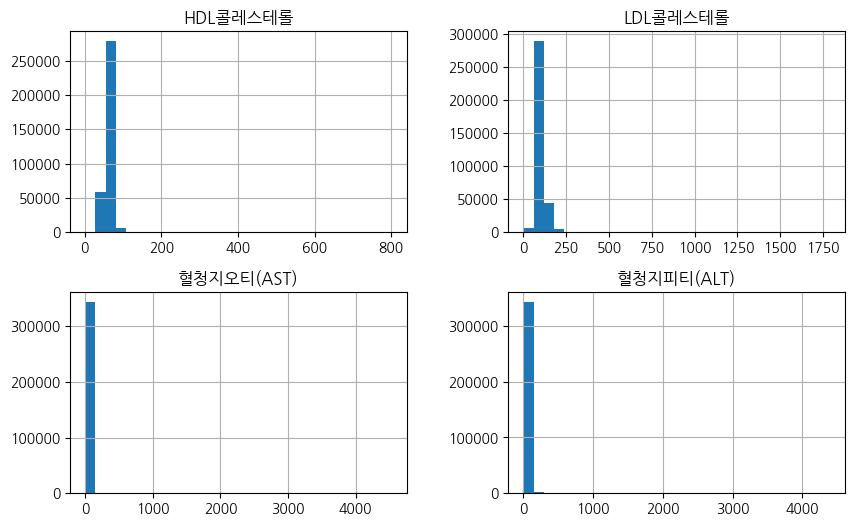

In [186]:
q1=df['HDL콜레스테롤'].quantile(0.25)
q3=df['HDL콜레스테롤'].quantile(0.75)
iqr=q3-q1
# iqr이 0으로 나오는데 아마 결측치를 대체를 많이해서 이런결과가 나오는것같다
cols = ["HDL콜레스테롤","LDL콜레스테롤","혈청지오티(AST)","혈청지피티(ALT)"]
df[cols].describe() # 최댓값이 너무 극단적으로 크다
df[cols].hist(bins=30, figsize=(10,6))
#히스토그램을 살펴보면 콜레스테롤 두종류는 극단적인값이 소수가 있단고 판단 / AST,ALT는 결측치 대체말고 제거를 해야했다...

### 속성 간의 관계 살펴보기

#### 문제11 : 상관관계 분석하기
- 수치형 데이터 간의 상관 관계를 계산하고 히트맵을 사용해 시각화해보세요.

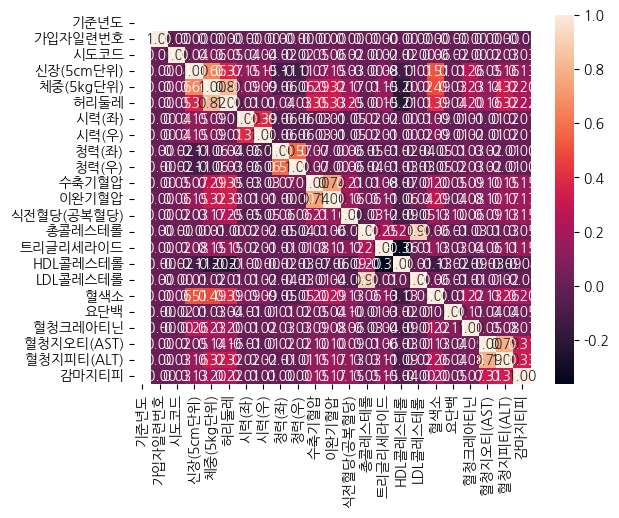

In [187]:
numeric_df.head(5)
corr= numeric_df.corr()
sns.heatmap(corr,annot=True,fmt='0.2f')
plt.show()

In [ ]:
# 위 시각화에서 찾을 수 있는 관계성은 어떤 것이 있나요?
너무 많아 해석하기 어렵지만 확실한건 빼야 할 수치형 변수가 보인다 (흡연상태,치석,구강검진수검여부)

#### 문제12 : 수치형 변수들 간의 산점도 및 각 변수의 히스토그램을 그려 보세요

- 4가지 변수('신장(5cm단위)', '체중(5kg단위)', '허리둘레', '수축기혈압')에 대한 시각화를 진행해보세요.

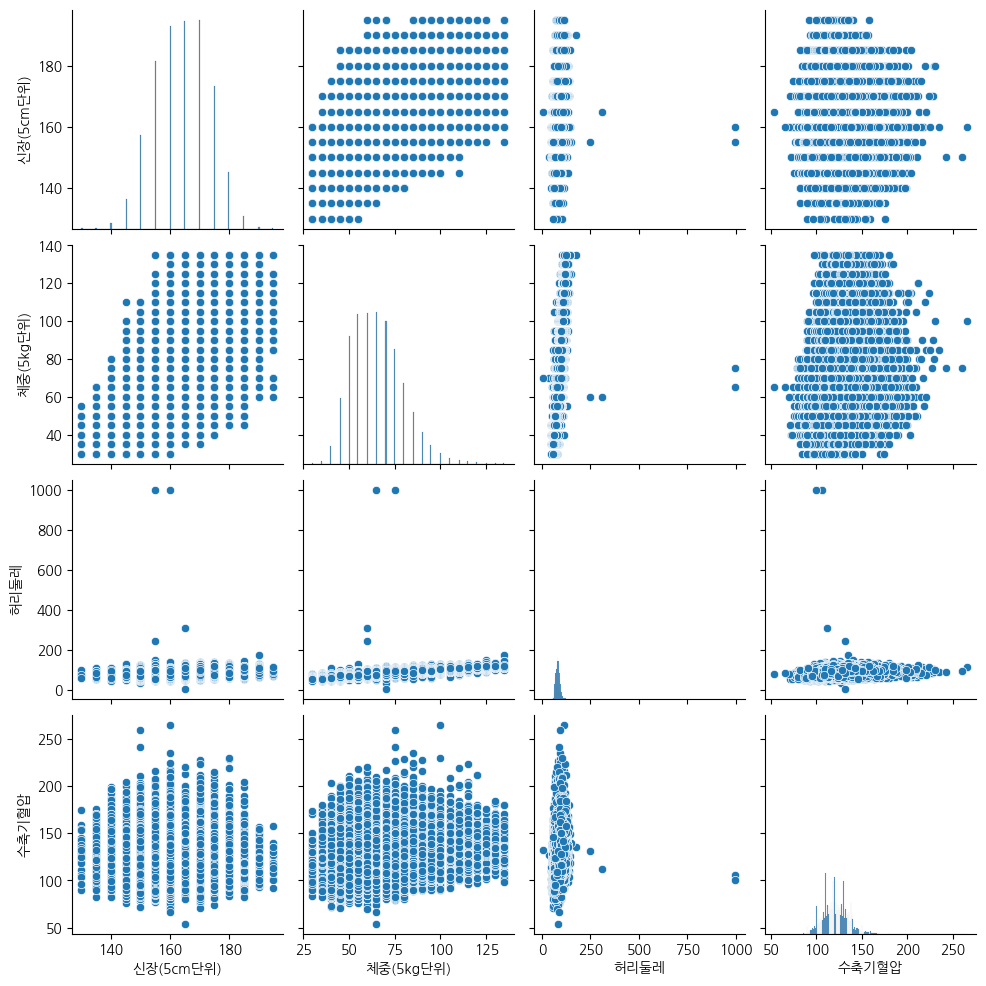

In [188]:
# 수치형 변수들에 대한 Pair Plot 그리기
cols2=['신장(5cm단위)', '체중(5kg단위)', '허리둘레', '수축기혈압']
plot_df =df[cols2]
sns.pairplot(plot_df, diag_kind='hist')
plt.show()

#### 문제13 : 성별에 따른 몇 가지 주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압)의 기술 통계 비교하기

- 범주형 변수에 따른 수치형 변수의 분포 분석해봅시다. 성별이 주요 건강 지표(신장, 체중, 허리둘레, 수축기혈압)에 어떻게 영향을 미치는지 파악하고 싶습니다.

- 카테고리별 수치형 변수의 기술 통계 분석: 각 카테고리별로 수치형 변수의 평균, 중앙값, 분산 등을 비교합니다.

In [189]:
sex_df=df.groupby("성별")[cols2].agg(['mean','median','var',])
sex_df

신장(5cm단위)                    체중(5kg단위)                          허리둘레  \
          mean median        var       mean median         var       mean   
성별                                                                          
1   169.708237  170.0  43.320796  72.603291   70.0  154.249036  86.044331   
2   156.455034  155.0  39.616938  56.327692   55.0  103.232472  75.941499   

                            수축기혈압                     
   median         var        mean median         var  
성별                                                    
1    85.5   82.739840  124.076713  123.0  171.493379  
2    75.0  107.593079  118.086267  117.0  212.840783

#### 문제14 : 성별에 따른 몇 가지 주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압)의 분포를 비교하기

- 성별에 따른 몇 가지 주요 수치형 변수(신장, 체중, 허리둘레, 수축기혈압)의 분포를 시각화하여 비교해보세요.
- 시각화 방법은 자유롭게 선택하셔도 됩니다.

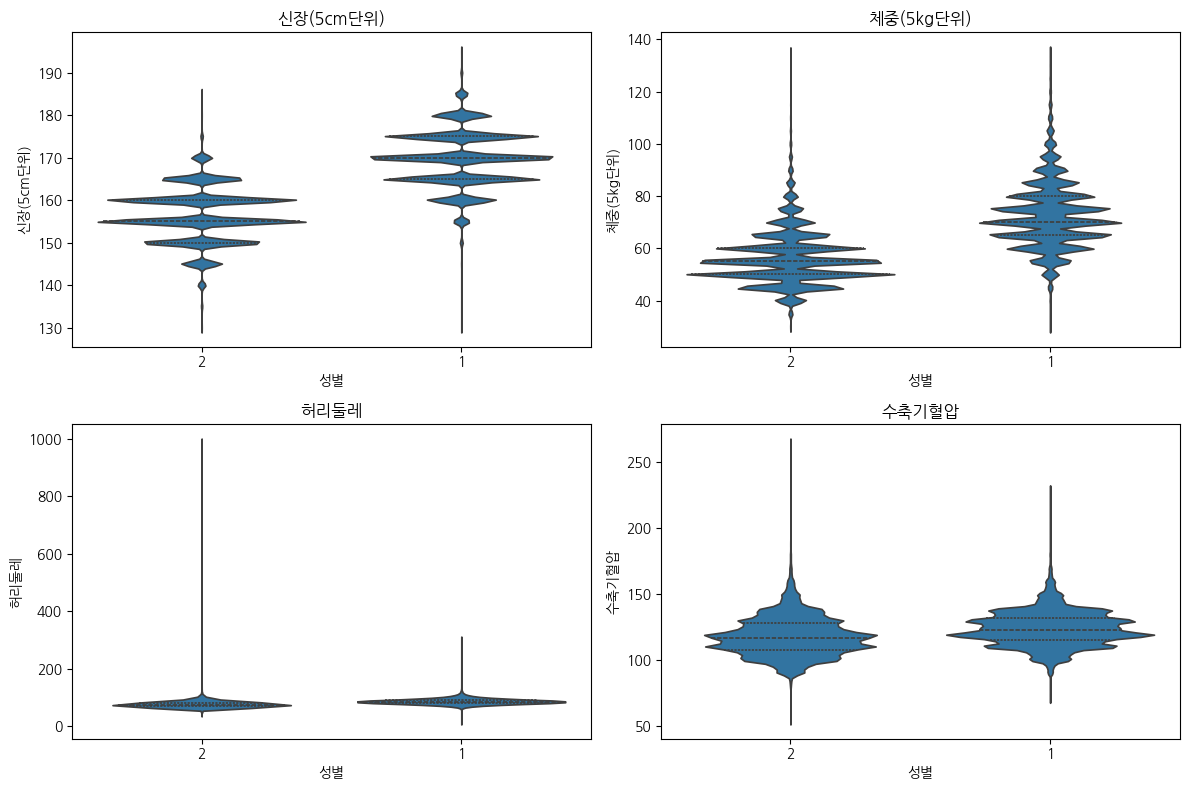

In [190]:
sex_df = df[['성별'] + cols2].copy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, cols2):
    sns.violinplot(data=sex_df, x='성별', y=col, inner='quartile', ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
신장과 체중은 분포차이가 뚜렷하다. 그리고 수축기 혈압은 성별간의 차이가 크게 없다. 허리둘레는 성별2이 극단 이상치가 있다.

#### 문제15 : 성별에 따른 흡연상태의 비율을 시각화해보세요

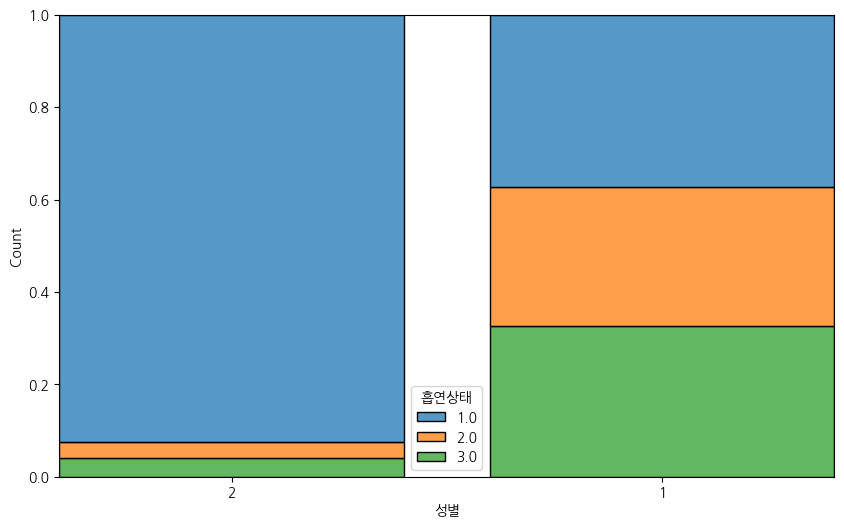

In [192]:
plt.figure(figsize=(10,6))
ax = sns.histplot(data=df, x='성별', hue='흡연상태', multiple='fill',shrink=0.8)

plt.show()

In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
성별 2는 흡연상태 1의 비율이 거의 대부분인 반면, 성별 1은 1,2,3의 비율이 각각 분포해 있습니다.

#### 문제16 : 연령대별로 주요 건강 지표(신장, 체중, 허리둘레, 수축기혈압)를 분석해보세요.
- 연령대별로 이러한 지표들의 평균 값을 계산하여 피봇테이블을 생성하세요.

In [193]:
pivot=pd.pivot_table(df, index='연령대코드(5세단위)',values=cols2,aggfunc='mean')
pivot

,수축기혈압,신장(5cm단위),체중(5kg단위),허리둘레
연령대코드(5세단위),,,,
20-24,114.914822,164.470738,62.655216,75.276094
25-29,116.877400,166.385343,66.064224,78.240476
30-34,117.957969,167.262612,68.627115,80.989638
35-39,119.896194,167.654393,70.135777,82.845287
40-44,120.056787,166.615884,68.569535,82.435278
45-49,121.284328,165.182648,67.011443,82.116498
50-54,122.214546,163.173699,64.896709,81.792677
55-59,123.638924,161.598034,63.369583,82.033888
60-64,124.782104,159.816635,61.728044,82.351612


In [ ]:
# 위 데이터에서 어떤 인사이트를 확인할 수 있나요?
연령대가 올라갈수록 수축기혈압은 높아져가고, 허리둘레는 천천히 증가한다.

#### 문제17 : 각 지표별로 연령대에 따른 평균값의 변화 추이를 그래프로 시각화해보세요.

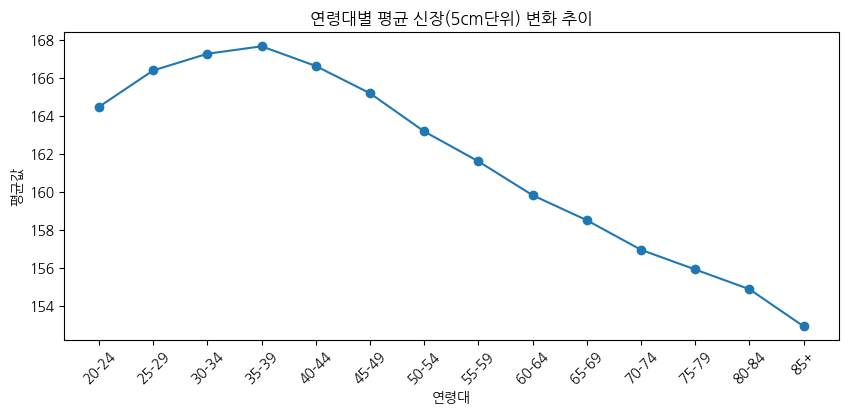

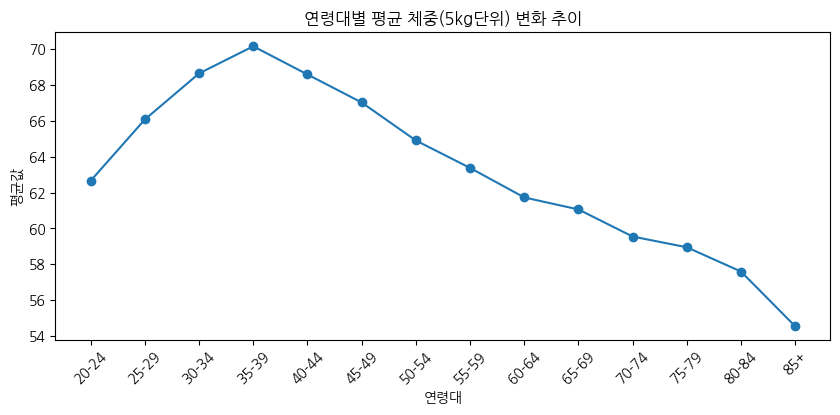

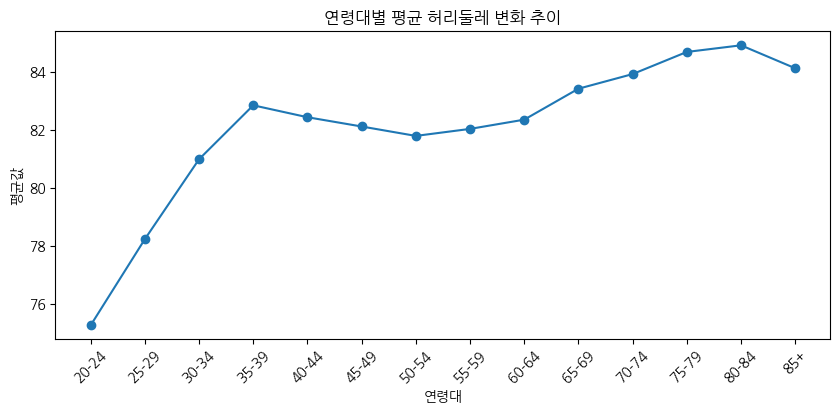

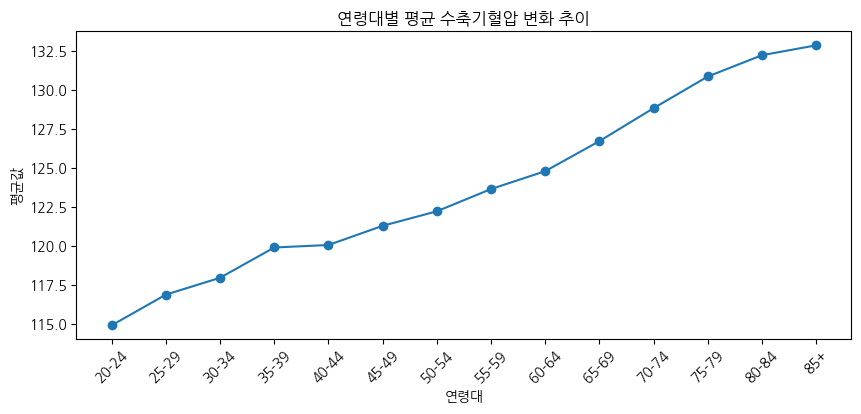

In [194]:
for col in cols2:
    plt.figure(figsize=(10,4))
    plt.plot(pivot.index, pivot[col], marker='o')
    plt.title(f'연령대별 평균 {col} 변화 추이')
    plt.xlabel('연령대')
    plt.ylabel('평균값')
    plt.xticks(rotation=45)
    plt.show()

#### 문제18 : BMI를 계산하고, 각 범주별로 분류해부세요.

체질량 지수(BMI)는 개인의 체중(kg)을 신장(m)의 제곱으로 나눈 값으로 계산하며, 비만도를 판단하는 데 널리 사용됩니다. BMI를 계산하여 각 개인의 비만도를 분류해보세요.


$$BMI= \frac{체중(kg)}{신장(m)^2}$$

BMI에 따른 비만도 분류는 다음과 같습니다:

- 저체중: BMI < 18.5
- 정상 체중: 18.5 ≤ BMI < 25
- 과체중: 25 ≤ BMI < 30
- 비만: BMI ≥ 30

세계보건기구(WHO)의 BMI 분류는 다음과 같습니다:

- 저체중: BMI < 18.5
- 정상: 18.5 ≤ BMI < 24.9
- 과체중: 24.9 ≤ BMI < 30
- 비만: BMI ≥ 30

In [198]:
df.head(2)
df['bmi']=round(df['체중(5kg단위)']/((df['신장(5cm단위)']/100)**2),1)
bmi_max= df['bmi'].max()+1
df['비만도']=pd.cut(df['bmi'],bins=[0,18.5,24.9,30,bmi_max],labels=['저체중','정상','과체중','비만'],right=False)
df.head(10)

,기준년도,가입자일련번호,시도코드,성별,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),청력(좌),청력(우),수축기혈압,이완기혈압,식전혈당(공복혈당),총콜레스테롤,트리글리세라이드,HDL콜레스테롤,LDL콜레스테롤,혈색소,요단백,혈청크레아티닌,혈청지오티(AST),혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,치석,bmi,비만도
0,2022,702763,41,2,65-69,160,75,89.0,1.0,1.0,1.0,1.0,127.0,73.0,84.0,198.0,131.9,56.9,115.5,14.8,1.0,0.8,25.0,20.0,15.0,1.0,0.0,0,0.0,1.0,29.3,과체중
18435,2022,443680,41,2,30-34,155,60,80.0,1.0,1.2,1.0,1.0,112.0,70.0,89.0,198.0,131.9,56.9,115.5,11.7,1.0,0.8,18.0,12.0,8.0,1.0,0.0,1,0.0,1.0,25.0,과체중
18440,2022,4889777,41,1,35-39,170,80,85.0,1.0,1.5,1.0,1.0,167.0,96.0,96.0,198.0,131.9,56.9,115.5,15.5,1.0,0.8,20.0,22.0,52.0,2.0,1.0,1,1.0,1.0,27.7,과체중
18441,2022,2907679,41,1,65-69,165,60,85.0,0.5,0.9,1.0,1.0,130.0,80.0,147.0,198.0,131.9,56.9,115.5,14.5,1.0,0.8,26.0,19.0,24.0,1.0,1.0,1,0.0,1.0,22.0,정상
18442,2022,4631243,41,1,35-39,170,70,85.0,1.0,0.5,1.0,1.0,130.0,80.0,89.0,198.0,131.9,56.9,115.5,15.6,1.0,0.8,20.0,13.0,33.0,1.0,1.0,1,0.0,0.0,24.2,정상
18443,2022,1173218,41,1,25-29,185,85,85.0,0.2,1.2,1.0,1.0,135.0,79.0,109.0,198.0,131.9,56.9,115.5,15.9,1.0,0.8,46.0,62.0,49.0,3.0,1.0,1,1.0,1.0,24.8,정상
18447,2022,3641198,41,1,60-64,150,60,80.0,9.9,0.5,1.0,1.0,137.0,77.0,135.0,198.0,131.9,56.9,115.5,15.1,1.0,0.8,33.0,36.0,37.0,1.0,0.0,1,1.0,1.0,26.7,과체중
18448,2022,4411868,41,1,55-59,160,65,85.0,0.8,0.6,1.0,1.0,141.0,89.0,99.0,198.0,131.9,56.9,115.5,15.5,1.0,0.8,32.0,33.0,40.0,1.0,1.0,1,0.0,1.0,25.4,과체중
18450,2022,3345757,41,2,55-59,145,50,80.0,0.5,0.7,1.0,1.0,123.0,77.0,74.0,198.0,131.9,56.9,115.5,13.5,1.0,0.8,63.0,34.0,16.0,1.0,0.0,1,0.0,1.0,23.8,정상
18451,2022,1267384,41,1,35-39,170,70,85.0,1.2,1.2,1.0,1.0,105.0,62.0,90.0,198.0,131.9,56.9,115.5,15.2,1.0,0.8,22.0,37.0,23.0,1.0,1.0,1,0.0,1.0,24.2,정상


#### 문제19 : BMI 대한 기초 통계량을 확인해보세요.

In [202]:
# BMI에 관한 기초 통계량 계산
df['bmi'].describe()
#df['bmi'].isna().sum()

count    344268.000000
mean         24.213197
std           3.954815
min          11.700000
25%          21.500000
50%          23.900000
75%          26.200000
max          56.200000
Name: bmi, dtype: float64

In [200]:
df['비만도'].describe()

count     344268
unique         4
top           정상
freq      191413
Name: 비만도, dtype: object

#### 문제20 : BMI에 대한 분포를 더 자세히 살펴보기 위해 히스토그램과 박스 플롯을 사용해 시각화해보세요.

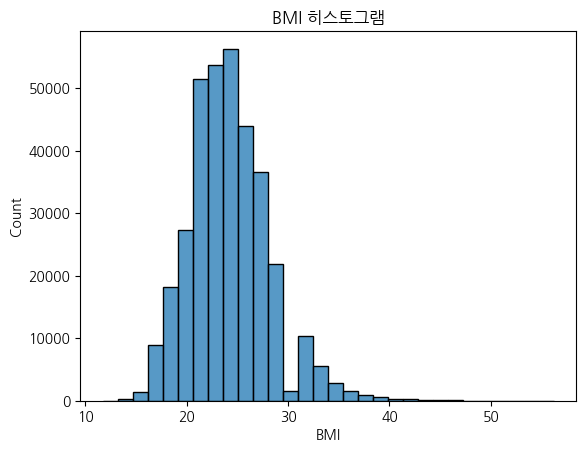

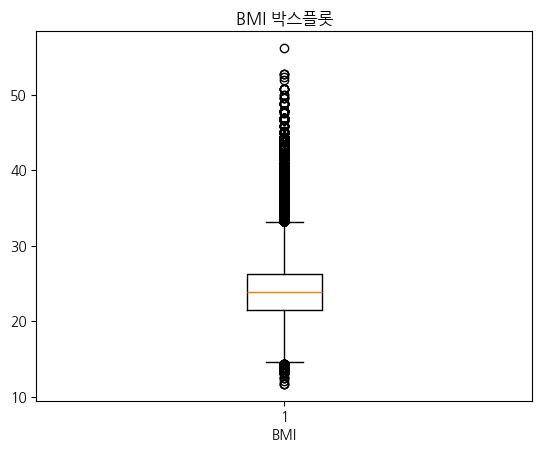

In [210]:
sns.histplot(df['bmi'], bins=30)
plt.title("BMI 히스토그램")
plt.xlabel("BMI")
plt.show()
#________________________________________________
plt.boxplot(x=df['bmi'])
plt.title("BMI 박스플롯")
plt.xlabel("BMI")
plt.show()

In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
두 시각화를 보면 히스토그램에 30이상으로 분포되어있다는게 보이면서 박스플롯을 확인하면 확실히 이상치값이 있다고 정확하게 확인할수있다 

#### 문제21 : BMI 범주별 분포를 분석해보세요.
- 위에서 분류한 각 범주별로 인구 분포를 확인해보세요.

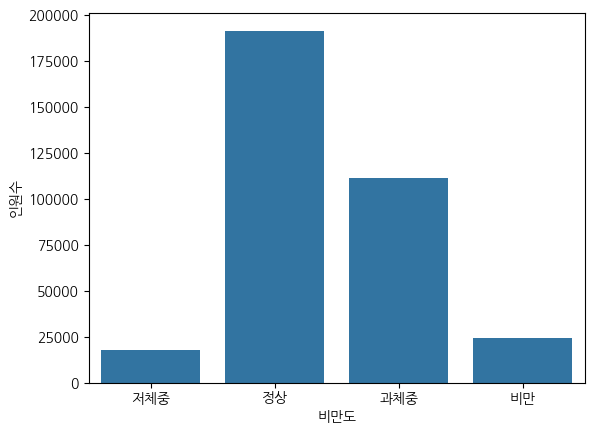

In [214]:
count_df = df['비만도'].value_counts().reset_index()
count_df.columns = ['비만도','인원수']
sns.barplot(data=count_df, x='비만도', y='인원수',order=['저체중','정상','과체중','비만'])
plt.show()

In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
이 분포를 보면 정상체중,과체중이 가장 분포가 많아서 표본이 불균형한 분포인것같다.

#### 문제22 : 비만도(BMI 범주)와 다른 건강 지표(수축기혈압, 이완기혈압, 식전혈당) 간의 관계를 살펴보세요
- 기술 통계와 시각화를 모두 진행해주세요.

In [226]:
df.describe()
bmi_df=df.groupby('비만도',observed=False)[['수축기혈압','이완기혈압', '식전혈당(공복혈당)']].agg(['count','mean','median','std','min','max'])
bmi_df

수축기혈압                                              이완기혈압             \
      count        mean median        std   min    max   count       mean   
비만도                                                                         
저체중   17653  111.719606  110.0  12.860405  71.0  203.0   17653  69.509420   
정상   191413  119.049507  118.0  13.593224  54.0  229.0  191413  73.432164   
과체중  111097  125.272349  125.0  13.221057  66.0  227.0  111097  77.639213   
비만    24105  129.870906  130.0  13.718892  83.0  265.0   24105  81.239817   

                                   식전혈당(공복혈당)                                \
    median        std   min    max      count        mean median        std   
비만도                                                                           
저체중   69.0   9.028837  38.0  120.0      17653   91.922563   90.0  15.263505   
정상    73.0   9.499842  10.0  144.0     191413   97.627152   94.0  19.128772   
과체중   78.0   9.588888  29.0  150.0     111097  103.508619   99.0  22.983444   
비만    80.0  10.357990  45.0  170.0      24105  108.412321  101.0  29.775315   

                  
      min    max  
비만도               
저체중  42.0  426.0  
정상   33.0  561.0  
과체중  45.0  593.0  
비만   52.0  628.0

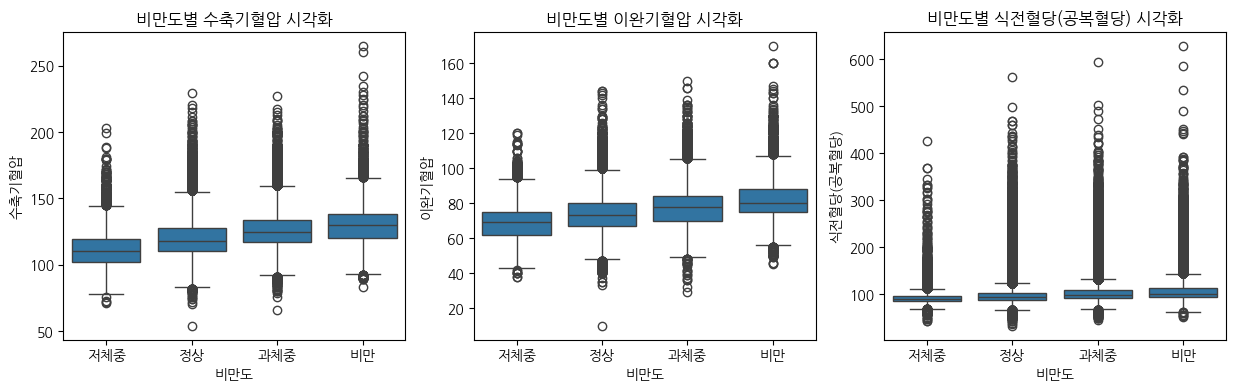

In [227]:
#________________________________________________________________-
cols=['수축기혈압','이완기혈압', '식전혈당(공복혈당)']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax,col in zip(axes,cols):
    sns.boxplot(data=df, x='비만도', y=col, order=['저체중','정상','과체중','비만'], ax=ax)
    ax.set_title(f"비만도별 {col} 시각화")
plt.show()    

In [ ]:
# 위 데이터에서 어떤 인사이트를 확인할 수 있나요?
비만도범주가 증가함에 따라 수축기혈압,이완기 혈압, 공복혈당 증가하는 형태를 보인다.

#### 문제23 : 연령대 및 성별에 따른 BMI 변화를 분석해보세요.
- 연령대가 증가함에 따라 BMI가 어떻게 변화하는지, 그리고 남성과 여성 간의 차이가 있는지를 파악해보세요.
- 데이터를 성별과 연령대 코드로 그룹화하여 각 그룹의 평균 BMI를 계산하고 시각화해보세요.  

In [230]:
df.head(1)
bmi_pivot= pd.pivot_table(df, index='연령대코드(5세단위)', columns='성별', values='bmi', aggfunc='mean')
bmi_pivot

성별,1,2
연령대코드(5세단위),,
20-24,24.501828,21.924682
25-29,25.098652,21.928855
30-34,25.697304,22.294600
35-39,25.927312,22.640172
40-44,25.670320,22.776607
45-49,25.345335,23.038597
50-54,25.076645,23.247857
55-59,24.729565,23.491895
60-64,24.483957,23.669226


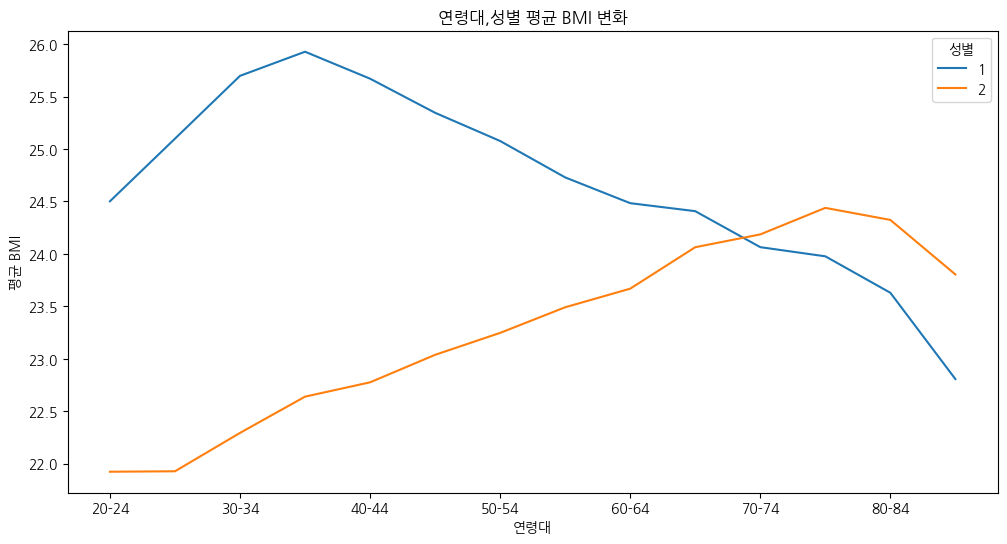

In [231]:
bmi_pivot.plot(figsize=(12,6))
plt.title("연령대,성별 평균 BMI 변화")
plt.xlabel("연령대")
plt.ylabel("평균 BMI")
plt.show()

In [ ]:
# 위 시각화에서 어떤 인사이트를 확인할 수 있나요?
성별 1은 30-34에서 최고점을 찍다가 감소하고, 성별2은 증가하는 경향을 보이고 80-84에서 감소한다.

## 마무리

다양한 통계 및 시각화 분석을 진행하였습니다. 모두들 수고하셨습니다.    
제공된 문제 이외에도 다양한 분석을 진행할 수 있습니다. 마음껏 도전해보세요!